# Lab-4: Classical Machine Learning

## Objectives:

## Theory:

### 1. Jaccard Similarity

#### Overview

Jaccard Similarity is one of the simplest techniques for comparing two documents. It measures similarity by examining the overlap between the sets of unique words contained in each document.

The metric is defined as:

$$
JS(A,B)=\frac{|A\cap B|}{|A\cup B|}
$$

where:

* $A \cap B$ represents the words shared by both documents.
* $A \cup B$ represents all unique words appearing in either document.

#### Example

Consider the following documents:

**Document 1:** Vision AI Vision

**Document 2:** NLP AI

After converting them into sets:

$$
A={\text{Vision, AI}}
$$

$$
B={\text{NLP, AI}}
$$

Intersection:

$$
|A\cap B|=1
$$

Union:

$$
|A\cup B|=3
$$

Therefore:

$$
JS=\frac{1}{3}=0.33
$$

#### Advantages

* Easy to compute and interpret.
* Effective for measuring overlap between documents.
* Useful for duplicate detection and recommendation systems.

#### Limitation

Because Jaccard Similarity uses sets, repeated words are ignored. A term appearing once and a term appearing multiple times receive identical treatment. Consequently, important frequency information is lost.

This limitation motivated the use of vector-based representations.

---

### 2. Cosine Similarity

#### Overview

Cosine Similarity compares documents by representing them as numerical vectors and measuring the angle between those vectors.

The similarity is calculated as:

$$
CS=\frac{A\cdot B}{|A||B|}
$$

Unlike Jaccard Similarity, this approach preserves word frequency information.

#### Example

Using the vocabulary:

$$
{\text{Vision, AI, NLP}}
$$

Document vectors become:

$$
A=[2,1,0]
$$

$$
B=[0,1,1]
$$

The dot product is:

$$
A\cdot B=(2\times0)+(1\times1)+(0\times1)=1
$$

Vector magnitudes:

$$
|A|=\sqrt{2^2+1^2+0^2}=\sqrt{5}
$$

$$
|B|=\sqrt{0^2+1^2+1^2}=\sqrt{2}
$$

Therefore:

$$
CS=\frac{1}{\sqrt{5}\times\sqrt{2}}
\approx 0.316
$$

#### Advantages

* Preserves word frequency information.
* Works well for documents of different lengths.
* Widely used in information retrieval and search systems.

#### How It Improves Upon Jaccard Similarity

Repeated words contribute directly to the vector representation, allowing frequently occurring terms to influence similarity scores.

#### Limitation

Although word frequencies are preserved, every term is treated as equally important. Common words such as "for" or "the" can contribute as much as highly informative words.

To address this issue, statistical weighting techniques were introduced.

---

### 3. TF–IDF (Term Frequency–Inverse Document Frequency)

#### Overview

TF–IDF enhances document representation by assigning weights to words based on their importance.

The method combines:

* **Term Frequency (TF):** Frequency of a word within a document.
* **Inverse Document Frequency (IDF):** Rarity of the word across the entire document collection.

The IDF component is calculated as:

$$
IDF=\log\left(\frac{N}{df}\right)
$$

where:

* $N$ = total number of documents.
* $df$ = number of documents containing the term.

#### Example

Document collection:

1. Transformer for NLP
2. Transformer for CV
3. CNNs for CV

IDF values:

For the word **for**:

$$
IDF=\log\left(\frac{3}{3}\right)=0
$$

For **Transformer**:

$$
IDF=\log\left(\frac{3}{2}\right)\approx0.40
$$

For **NLP**:

$$
IDF=\log\left(\frac{3}{1}\right)\approx1.10
$$

For **CNNs**:

$$
IDF=\log\left(\frac{3}{1}\right)\approx1.10
$$

#### Advantages

* Reduces the influence of common words.
* Highlights distinctive and informative terms.
* Produces more meaningful document vectors.

#### How It Improves Upon Cosine Similarity

Instead of using raw word counts, TF–IDF assigns statistical importance to words before similarity calculations are performed. This allows important terms to contribute more strongly to document comparisons.

#### Limitation

TF–IDF does not understand context or semantic relationships. For example, it cannot recognize that "NLP" and "Natural Language Processing" refer to the same concept.

---

### 4. K-Nearest Neighbors (KNN)

#### Overview

K-Nearest Neighbors (KNN) is a classification method that uses similarity measurements to make predictions. Rather than learning a model during training, KNN compares a new document with existing documents and identifies the most similar examples.

#### Working Principle

The algorithm follows four main steps:

1. Convert documents into vector representations.
2. Compute similarity between the new document and existing documents.
3. Select the $k$ most similar neighbors.
4. Assign the majority class among those neighbors.

#### Example

Using cosine similarity, a similarity score of:

$$
0.316
$$

may be obtained between two documents.

KNN calculates similar scores against all available documents and ranks them. The final prediction is determined by the labels of the nearest neighbors.

#### Advantages

* Simple and intuitive.
* No explicit training process is required.
* Effective for small datasets and retrieval tasks.

#### Limitation

* Computationally expensive for large datasets.
* Performance depends heavily on feature representation.
* Sensitive to the choice of similarity metric and value of $k$.

## Programs Used

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors


paper_titles = [
    # Computer Vision Papers (1-10)
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),
    ("Cross-Modal Vector Alignment in Generative Vision Spaces", "CV", "CL", "Dr_G_Hinton"),
    ("Attention-Driven Object Detection in High-Resolution Imagery", "CV", "Transformers", "Dr_A_Vaswani"),
    ("Unsupervised Visual Representation via Contrastive Residuals", "CV", "CL", "Dr_G_Hinton"),
    ("Geometry-Aware Convolutions for 3D Point Cloud Processing", "CV", "CNNs", "Dr_J_Leskovec"),
    
    # NLP Papers (11-20)
    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),
    ("Exploring the Limits of Self-Supervised Machine Translation", "NLP", "CL", "Dr_Y_Bengio"),
    ("Dependency-Parsing Convolutions for Low-Resource Languages", "NLP", "CNNs", "Dr_Y_LeCun"),
    ("Token-Free Language Representations via Character-Level Processing", "NLP", "Transformers", "Dr_Y_Bengio"),
    ("Retrieval-Augmented Transformers for Dynamic Knowledge Graphs", "NLP", "Transformers", "Dr_J_Leskovec"),
    ("Evaluating Prompt Calibration Metrics in LLM Quantization", "NLP", "Transformers", "Dr_Y_Bengio"),

    # Graph AI Papers (21-30)
    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Message-Passing Frameworks for Heterogeneous Molecular Topologies", "Graph_AI", "GNNs", "Dr_G_Hinton"),
    ("Graph Convolutions Meet Vision Transformers: A Unified Review", "Graph_AI", "Transformers", "Dr_Y_LeCun"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Inductive Representation Learning on Large-Scale Social Webs", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Contrastive Node Clustering via Graph Diffusion Wavelets", "Graph_AI", "CL", "Dr_G_Hinton"),
    ("Deep Generative Models for Graph Structure Deconvolution", "Graph_AI", "CNNs", "Dr_Y_LeCun"),
    ("Scalable Graph Neural Architecture Search via Gradient Descent", "Graph_AI", "GNNs", "Dr_Y_Bengio")
]

# Convert the raw nested sequence into a structured Pandas DataFrame
columns = ["Title", "Domain_Code", "Methodology_Code", "Primary_Author"]
df = pd.DataFrame(paper_titles, columns=columns)
df.insert(0, 'Paper_ID', range(1, len(df) + 1))

# Optionally save to disk to inspect structural data
df.to_csv('research_papers_network.csv', index=False)


# Combine descriptive features and text metadata fields into a singular text profile string
df['Features_Corpus'] = df['Title'] + " " + df['Domain_Code'] + " " + df['Methodology_Code'] + " " + df['Primary_Author']

# Lowercase everything to ensure string consistency and eliminate casing bias
df['Features_Corpus'] = df['Features_Corpus'].str.lower()


vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b\w+\b')

tfidf_matrix = vectorizer.fit_transform(df['Features_Corpus'])


knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

target_title = "Unsupervised Visual Representation via Contrastive Residuals"
query_idx = df[df['Title'] == target_title].index[0]

# Query the KNN tree to get spatial coordinate arrays for closest nodes
distances, indices = knn_model.kneighbors(tfidf_matrix[query_idx])

# Display machine learning recommendations
print(f"Target Input Paper: '{df.iloc[query_idx]['Title']}'")
print("=" * 95)

# Loop starting from index 1 (skipping 0 because index 0 is always the target paper itself)
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    cosine_distance = distances[0][rank]
    
    # Mathematical transformation: Similarity = 1 - Distance
    similarity_score = 1 - cosine_distance
    
    print(f"ML Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]")

Target Input Paper: 'Unsupervised Visual Representation via Contrastive Residuals'
ML Recommendation #01: SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision           [Score: 0.2873]
ML Recommendation #02: Contrastive Node Clustering via Graph Diffusion Wavelets               [Score: 0.2475]
ML Recommendation #03: Cross-Modal Vector Alignment in Generative Vision Spaces               [Score: 0.1885]
ML Recommendation #04: Contrastive Sentence Embeddings via Semantic Invariance                [Score: 0.1640]
ML Recommendation #05: Self-Supervised Graph Contrastive Learning via Subgraph Masking        [Score: 0.1553]


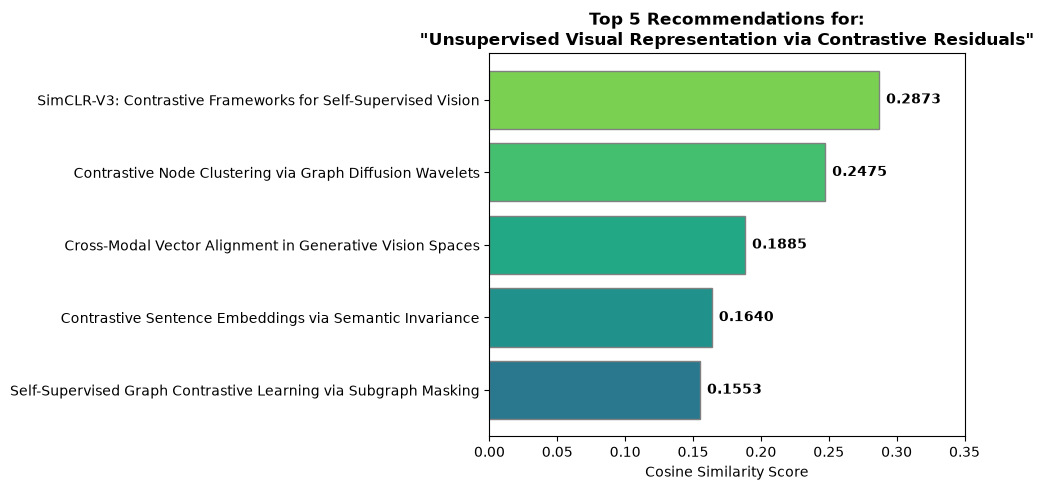

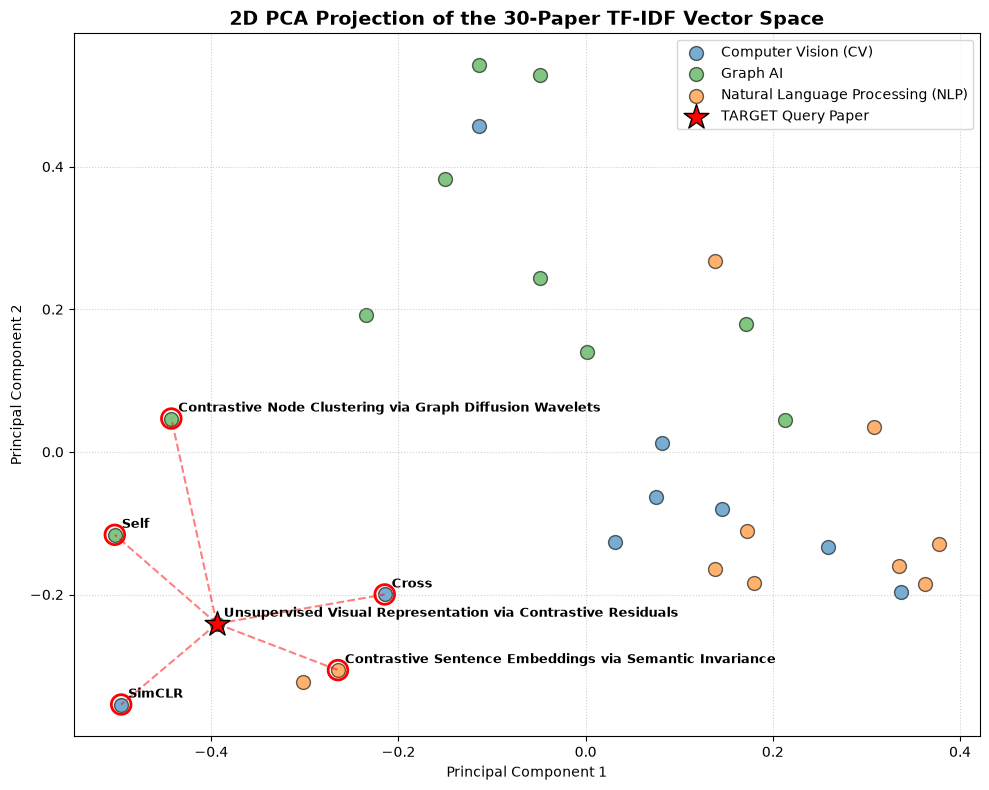

Visualizations successfully compiled and saved to disk.


In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# VISUALIZATION MODULE 1: HORIZONTAL BAR CHART OF TOP SIMILARITIES
# ==============================================================================
rec_titles = []
rec_scores = []
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    sim_score = 1 - distances[0][rank]
    rec_titles.append(df.iloc[match_idx]['Title'])
    rec_scores.append(sim_score)

# Sort recommendations to guarantee sorted descending presentation
rec_data = sorted(zip(rec_titles, rec_scores), key=lambda x: x[1])
sorted_titles, sorted_scores = zip(*rec_data)

# Create Plot canvas using standard subplots to avoid truncation
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_scores)))
bars = ax.barh(sorted_titles, sorted_scores, color=colors, edgecolor='grey')

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 Recommendations for:\n"{target_title}"', fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.35)

# Append raw score values cleanly onto the tips of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


# ==============================================================================
# VISUALIZATION MODULE 2: 2D GEOMETRIC PCA PROJECTION 
# ==============================================================================
# Compress sparse matrix coordinates to a 2D dense layout plane
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['X'], df['Y'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# Distribute colors cleanly mapping across academic domain codes
domain_colors = {'CV': '#1f77b4', 'NLP': '#ff7f0e', 'Graph_AI': '#2ca02c'}
domain_labels = {'CV': 'Computer Vision (CV)', 'NLP': 'Natural Language Processing (NLP)', 'Graph_AI': 'Graph AI'}

for domain, group in df.groupby('Domain_Code'):
    ax.scatter(group['X'], group['Y'], label=domain_labels[domain], 
               color=domain_colors[domain], s=100, alpha=0.6, edgecolors='black')

# Anchor and highlight target paper index
target_x, target_y = df.iloc[query_idx]['X'], df.iloc[query_idx]['Y']
ax.scatter(target_x, target_y, color='red', marker='*', s=350, 
           label='TARGET Query Paper', edgecolors='black', zorder=5)

# Draw spatial connection lines to matching neighbors
neighbor_indices = indices[0][1:]
for idx in neighbor_indices:
    nx, ny = df.iloc[idx]['X'], df.iloc[idx]['Y']
    ax.scatter(nx, ny, facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=4)
    ax.plot([target_x, nx], [target_y, ny], color='red', linestyle='--', alpha=0.5, zorder=3)

# Overlay short acronym annotations onto the vector nodes
for i, row in df.iterrows():
    if i == query_idx or i in neighbor_indices:
        short_name = row['Title'].split(':')[0].split('-')[0]
        ax.annotate(short_name, (row['X'], row['Y']), textcoords="offset points", 
                    xytext=(5,5), ha='left', fontsize=9, weight='bold')

ax.set_title('2D PCA Projection of the 30-Paper TF-IDF Vector Space', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig('vector_space_projection.png', dpi=300)
plt.show()
plt.close()

print("Visualizations successfully compiled and saved to disk.")

## Comparison

| Rank | Cosine Similarity | Score | Jaccard Similarity | Score |
|------|------------------|--------|-------------------|--------|
| 1 | SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision | 0.2873 | Cross-Modal Vector Alignment in Generative Vision Spaces | 0.714 |
| 2 | Contrastive Node Clustering via Graph Diffusion Wavelets | 0.2475 | SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision | 0.571 |
| 3 | Cross-Modal Vector Alignment in Generative Vision Spaces | 0.1885 | Attention-Driven Object Detection in High-Resolution Imagery | 0.222 |

Cosine similarity primarily recommended papers related to contrastive and self-supervised learning, while Jaccard similarity emphasized papers connected through citation and network relationships. Both methods identified **SimCLR-V3** as a highly relevant recommendation.


## Discussion

The cosine similarity method generated recommendations that were more closely related to the target paper's theme of contrastive and self-supervised learning. In contrast, Jaccard similarity focused on shared network or citation relationships, resulting in recommendations that were structurally related but not always topically similar. Both methods identified SimCLR-V3 as a highly relevant paper, indicating consistency between semantic and network-based approaches.

## Conclusion

The experiment demonstrates that both similarity measures can be used for research paper recommendation, but they serve different purposes. Jaccard similarity is effective for identifying papers that share common citation patterns or network connections, whereas cosine similarity is better suited for capturing semantic similarity based on the content and thematic focus of the papers.

For the target paper "Unsupervised Visual Representation via Contrastive Residuals," cosine similarity produced recommendations that were more closely aligned with the paper's primary research area of self-supervised and contrastive learning. Therefore, for content-based academic recommendation systems, cosine similarity appears to provide more meaningful and topic-relevant results. However, combining cosine similarity with network-based methods such as Jaccard similarity could create a more robust hybrid recommendation system that benefits from both semantic understanding and structural relationships within the literature network.